# **run_SpatialEx+：Panel 对角整合 + 跨组学（转录组↔蛋白组）对角整合**

本脚本基于 SpatialEx+ 模型，使用 Xenium Human Breast Cancer（Rep1 / Rep2）演示两种典型的“对角整合”任务：

- **Part A**：**Panel 对角整合** —— 两个切片各自只测到不同的基因 panel（Panel A / Panel B），SpatialEx+ 让两个切片都能拥有完整的 Panel A ∪ Panel B（来自 Tutorial 2）。
- **Part B**：**跨组学对角整合** —— 切片 1 是蛋白组，切片 2 是转录组，SpatialEx+ 让两个切片都拥有蛋白组 + 转录组的多组学表达（来自 Tutorial 4）。

## 0. SpatialEx+ 算法逻辑梳理

### 0.1 “对角整合（Diagonal Integration）”问题设定
两个切片各自只观测到部分组学/部分基因，如何在每个细胞处同时获得所有组学/所有基因？SpatialEx+ 用 **共享 H&E 表征空间 + 跨 panel 的循环回归** 来解决这个问题。

| 任务 | 切片 1 观测 | 切片 2 观测 | 目标 |
| ---- | ---------- | ---------- | ---- |
| Part A — Panel 对角整合 | Panel A 基因表达 | Panel B 基因表达 | 两个切片均得到 Panel A + Panel B |
| Part B — 跨组学对角整合 | 蛋白组（Panel A） | 转录组（Panel B） | 两个切片均得到 蛋白组 + 转录组 |

### 0.2 输入与预处理
1. 每个切片都做：`Read_Xenium / Preprocess_adata` → `Read_HE_image / Register_physical_to_pixel` → `Tiling_HE_patches` → `Extract_HE_patches_representaion`，最终得到 `adata.obsm['he']`（病理基础模型 UNI 嵌入）。
2. Part A 中通过 `Selection_by_name.csv` 把基因划分为 **Panel A / Panel B**，并用 `Preprocess_adata(adata, selected_genes=panelX)` 限定每个切片只保留对应 panel。
3. Part B 中切片 1 的蛋白表达用预处理好的 `cell_protein_matrix.h5ad` 读入并 `sc.pp.scale`；切片 2 的转录组按常规流程。

### 0.3 模型结构（SpatialExP）
- **两个 HGNN 主干**（`module_HA`、`module_HB`），分别把切片 1 / 切片 2 的 H&E 嵌入映射到各自观测到的 omics 空间（Panel A / Panel B）。
- **两个回归映射头**（`rm_AB`：把 Panel A 表达映射到 Panel B 空间；`rm_BA`：把 Panel B 表达映射到 Panel A 空间）。
- 训练同时优化：
   1. **重建损失**：HGNN 输出与对应切片观测的 omics 之间的 MSE。
   2. **循环映射损失**：`rm_AB / rm_BA` 在两个切片上互相翻译时的 MSE，让两个 omics 空间形成一致的对应关系（cycle-style）。

### 0.4 推断方式
- `inference_direct`：H&E + 图 → 直接通过 HGNN 输出，得到 **该切片本身观测到的那个 panel** 的预测（更准）。
- `inference_indirect`：H&E → HGNN 输出 → 再过一层 `rm_AB / rm_BA` 映射，得到 **另一切片观测的 panel** 的预测。

由此实现：
- 切片 1：本身有 Panel A，间接预测 Panel B（`panelB1`）。
- 切片 2：本身有 Panel B，间接预测 Panel A（`panelA2`）。
- 两个切片的测序区**之外**的 H&E patch + 重新构图，同样可走 `inference_direct/indirect` 拿到 `panelA?_out / panelB?_out`。

### 0.5 评估指标
- **PCC**：每基因的皮尔逊相关，幅度+趋势一致性。
- **SSIM**（基于空间图）：空间结构相似度。
- **CMD**：基因-基因协表达矩阵的偏差。

下面的脚本完整复现 Part A + Part B，并在评估阶段加入了**指标可视化**（每基因 PCC/SSIM/CMD 的分布、Top 基因柱状图、PCC vs SSIM 散点）。

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

import SpatialEx as se

# 训练设备
device = 'cuda:1'

# 公共路径与训练超参（与下方 Part A / Part B 共用）
data_root = '/data1/linxin/1/SpatialEx/data/raw_data/HBC/'
sample_name1 = 'Human_Breast_Cancer_Rep1'
sample_name2 = 'Human_Breast_Cancer_Rep2'
resolution = 64
num_neighbors = 7
epochs = 500

In [2]:
# 评估阶段通用：把每基因/每蛋白指标绘制为分布 + Top-N 条形图
def plot_metric_distribution(pcc, ssim, cmd, var_names, title_prefix='Slice'):
    pcc  = np.asarray(pcc).ravel()
    ssim = np.asarray(ssim).ravel()
    cmd  = np.asarray(cmd).ravel() if np.ndim(cmd) > 0 and np.size(cmd) > 1 else np.full_like(pcc, float(np.asarray(cmd).mean()))

    df = pd.DataFrame({'feature': list(var_names), 'PCC': pcc, 'SSIM': ssim, 'CMD': cmd})

    cmd_scalar = float(np.asarray(cmd).mean())

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sns.histplot(df['PCC'],  kde=True, ax=axes[0], color='#2E86AB'); axes[0].set_title(f'{title_prefix} - PCC 分布')
    sns.histplot(df['SSIM'], kde=True, ax=axes[1], color='#A23B72'); axes[1].set_title(f'{title_prefix} - SSIM 分布')
    axes[2].text(0.5, 0.5, f'CMD\n{cmd_scalar:.4f}', ha='center', va='center',
                 fontsize=24, color='#F18F01', transform=axes[2].transAxes)
    axes[2].set_title(f'{title_prefix} - CMD（矩阵级标量）')
    axes[2].axis('off')
    plt.tight_layout(); plt.show()

    return df

## 1. 公共路径与基本配置

数据目录约定如下（与本脚本路径一致）：
```
/data1/linxin/1/SpatialEx/data/raw_data/HBC/
├── Human_Breast_Cancer_Rep1/
│   ├── cell_feature_matrix.h5
│   ├── cell_protein_matrix.h5ad     # Part B 使用
│   ├── cells.csv
│   ├── Xenium_FFPE_Human_Breast_Cancer_Rep1_he_image.ome.tif
│   ├── Xenium_FFPE_Human_Breast_Cancer_Rep1_he_imagealignment.csv
│   ├── HBRC_Rep1_cell_coor.csv
│   └── HBRC_Rep1_Out_uni.npy
├── Human_Breast_Cancer_Rep2/
│   ├── cell_feature_matrix.h5
│   ├── cells.csv
│   ├── Xenium_FFPE_Human_Breast_Cancer_Rep2_he_image.ome.tif
│   ├── Xenium_FFPE_Human_Breast_Cancer_Rep2_he_imagealignment.csv
│   ├── HBRC_Rep2_cell_coor.csv
│   └── HBRC_Rep2_Out_uni.npy
└── Selection_by_name.csv             # Part A 的 panel 划分
```

In [3]:
# 公共路径与超参已在上方「导入依赖」代码格中定义；若修改路径只需改那一格即可。
pass

---
# Part A：Panel 对角整合（Tutorial 2）

切片 1 仅观测 Panel A，切片 2 仅观测 Panel B。SpatialEx+ 让两个切片都得到 Panel A + Panel B。

## A.1 数据准备

通过 `Selection_by_name.csv` 划分两组互不相交的基因 panel。

In [4]:
import os

# 读入 panel 划分表
selection = pd.read_csv(data_root + 'Selection_by_name.csv', index_col=0)
panelA = selection.index[selection['panelA']]
panelB = selection.index[selection['panelB']]

# Part A 的原始数据路径（后面评估也要用，所以在此统一定义）
file_path1          = data_root + sample_name1 + '/cell_feature_matrix.h5'
obs_path1           = data_root + sample_name1 + '/cells.csv'
img_path1           = data_root + sample_name1 + '/Xenium_FFPE_Human_Breast_Cancer_Rep1_he_image.ome.tif'
transform_mtx_path1 = data_root + sample_name1 + '/Xenium_FFPE_Human_Breast_Cancer_Rep1_he_imagealignment.csv'

file_path2          = data_root + sample_name2 + '/cell_feature_matrix.h5'
obs_path2           = data_root + sample_name2 + '/cells.csv'
img_path2           = data_root + sample_name2 + '/Xenium_FFPE_Human_Breast_Cancer_Rep2_he_image.ome.tif'
transform_mtx_path2 = data_root + sample_name2 + '/Xenium_FFPE_Human_Breast_Cancer_Rep2_he_imagealignment.csv'

### A.1.1 预处理 Slice 1（仅保留 Panel A）

In [5]:
# 缓存路径：首次跑完 UNI 编码后保存为 h5ad，后续直接读
cache_a1 = data_root + sample_name1 + '/adata_panelA_uni_res64.h5ad'

if os.path.exists(cache_a1):
    print(f'[Part A - Rep1] 直接读取缓存: {cache_a1}')
    adata1 = sc.read_h5ad(cache_a1)
else:
    print('[Part A - Rep1] 首次运行，开始预处理 + UNI 编码...')
    adata1 = se.pp.Read_Xenium(file_path1, obs_path1)
    adata1 = se.pp.Preprocess_adata(adata1, selected_genes=panelA)

    img, scale     = se.pp.Read_HE_image(img_path1)
    transform_mtx  = pd.read_csv(transform_mtx_path1, header=None).values
    adata1         = se.pp.Register_physical_to_pixel(adata1, transform_mtx, scale=scale)
    he_patches, adata1 = se.pp.Tiling_HE_patches(resolution, adata1, img)
    adata1 = se.pp.Extract_HE_patches_representaion(
        he_patches, store_key='he', adata=adata1, image_encoder='uni', device=device
    )
    adata1.write_h5ad(cache_a1)
    print(f'[Part A - Rep1] 缓存已保存: {cache_a1}')

print(f'adata1: {adata1.shape}, he={adata1.obsm["he"].shape}')

[Part A - Rep1] 直接读取缓存: /data1/linxin/1/SpatialEx/data/raw_data/HBC/Human_Breast_Cancer_Rep1/adata_panelA_uni_res64.h5ad
adata1: (161542, 150), he=(161542, 1024)


### A.1.2 预处理 Slice 2（仅保留 Panel B）

In [6]:
cache_a2 = data_root + sample_name2 + '/adata_panelB_uni_res64.h5ad'

if os.path.exists(cache_a2):
    print(f'[Part A - Rep2] 直接读取缓存: {cache_a2}')
    adata2 = sc.read_h5ad(cache_a2)
else:
    print('[Part A - Rep2] 首次运行，开始预处理 + UNI 编码...')
    adata2 = se.pp.Read_Xenium(file_path2, obs_path2)
    adata2 = se.pp.Preprocess_adata(adata2, selected_genes=panelB)

    img, scale     = se.pp.Read_HE_image(img_path2)
    transform_mtx  = pd.read_csv(transform_mtx_path2, header=None).values
    adata2         = se.pp.Register_physical_to_pixel(adata2, transform_mtx, scale=scale)
    he_patches, adata2 = se.pp.Tiling_HE_patches(resolution, adata2, img)
    adata2 = se.pp.Extract_HE_patches_representaion(
        he_patches, store_key='he', adata=adata2, image_encoder='uni', device=device
    )
    adata2.write_h5ad(cache_a2)
    print(f'[Part A - Rep2] 缓存已保存: {cache_a2}')

print(f'adata2: {adata2.shape}, he={adata2.obsm["he"].shape}')

[Part A - Rep2] 直接读取缓存: /data1/linxin/1/SpatialEx/data/raw_data/HBC/Human_Breast_Cancer_Rep2/adata_panelB_uni_res64.h5ad
adata2: (110947, 163), he=(110947, 1024)


## A.2 训练 SpatialEx+ 并互相补全 Panel

In [7]:
# 基于空间 KNN 构造两个切片的超图
graph1 = se.pp.Build_hypergraph_spatial_and_HE(adata1, num_neighbors, graph_kind='spatial', normalize=True, return_type='crs')
graph2 = se.pp.Build_hypergraph_spatial_and_HE(adata2, num_neighbors, graph_kind='spatial', normalize=True, return_type='crs')

spatialexp = se.SpatialExP(adata1, adata2, graph1, graph2, device=device, epochs=epochs, platform='Visium')
spatialexp.train()

# 用训练好的模型互相补全：Slice1 → Panel B，Slice2 → Panel A
panelB1, panelA2 = spatialexp.auto_inference()

161542  cells are included in its nearest spot!
110947  cells are included in its nearest spot!


=================================== Start training =========================================


100%|██████████| 500/500 [03:45<00:00,  2.21it/s]


In [8]:
# 测序区域之外的细胞坐标 + H&E patch 嵌入
# make_hbrc_out_uni.py（padding 版）对所有细胞提取 embedding，行数与 cell_coor.csv 一致
out_spatial1 = pd.read_csv(data_root + sample_name1 + '/HBRC_Rep1_cell_coor.csv', index_col=0)
out_spatial2 = pd.read_csv(data_root + sample_name2 + '/HBRC_Rep2_cell_coor.csv', index_col=0)
out_he1      = np.load(data_root + sample_name1 + '/HBRC_Rep1_Out_uni.npy')
out_he2      = np.load(data_root + sample_name2 + '/HBRC_Rep2_Out_uni.npy')

graph1_out = se.pp.Build_hypergraph(out_spatial1.values, num_neighbors=num_neighbors, normalize=True)
graph2_out = se.pp.Build_hypergraph(out_spatial2.values, num_neighbors=num_neighbors, normalize=True)

# 区外推断：indirect = HGNN + 回归映射，可以同时拿到本身和对侧 panel
panelA1_out = spatialexp.inference_indirect(out_he1, graph1_out, panel='panelA')
panelB1_out = spatialexp.inference_indirect(out_he1, graph1_out, panel='panelB')
panelA2_out = spatialexp.inference_indirect(out_he2, graph2_out, panel='panelA')
panelB2_out = spatialexp.inference_indirect(out_he2, graph2_out, panel='panelB')

## A.3 定量评估 + 指标可视化

用对应切片对应 panel 的真值（重新读 + `Preprocess_adata(..., selected_genes=panelX)`）做对比。

### A.3.1 在 Slice 1 上评估预测得到的 Panel B

x shape is  161542
cell number is less than 200000
Slice1 上预测 Panel B 评估，PCC:  0.2976311  SSIM:  0.34921157499929134  CMD:  0.3386197854064078


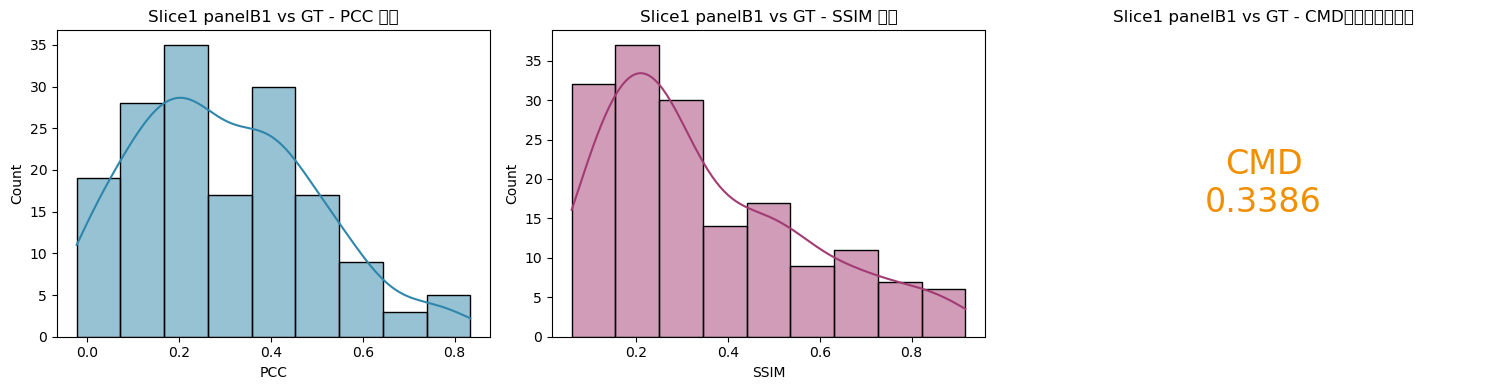

In [9]:
adata1_gt = se.pp.Read_Xenium(file_path1, obs_path1)[adata1.obs_names]
adata1_gt = se.pp.Preprocess_adata(adata1_gt, cell_mRNA_cutoff=0, selected_genes=panelB)

graph = se.pp.Build_graph(adata1_gt.obsm['spatial'], graph_type='knn', weighted='gaussian', apply_normalize='row', return_type='coo')
ssim, ssim_reduce = se.utils.Compute_metrics(adata1_gt.X.copy(), panelB1.copy(), metric='ssim', graph=graph, reduce='mean')
pcc,  pcc_reduce  = se.utils.Compute_metrics(adata1_gt.X.copy(), panelB1.copy(), metric='pcc',                  reduce='mean')
cmd,  cmd_reduce  = se.utils.Compute_metrics(adata1_gt.X.copy(), panelB1.copy(), metric='cmd',                  reduce='mean')
print('Slice1 上预测 Panel B 评估，PCC: ', pcc_reduce, ' SSIM: ', ssim_reduce, ' CMD: ', cmd_reduce)

_ = plot_metric_distribution(pcc, ssim, cmd, var_names=adata1_gt.var_names, title_prefix='Slice1 panelB1 vs GT')

### A.3.2 在 Slice 2 上评估预测得到的 Panel A

x shape is  110947
cell number is less than 200000
Slice2 上预测 Panel A 评估，PCC:  0.3089193  SSIM:  0.36017279243382083  CMD:  0.34495192824036813


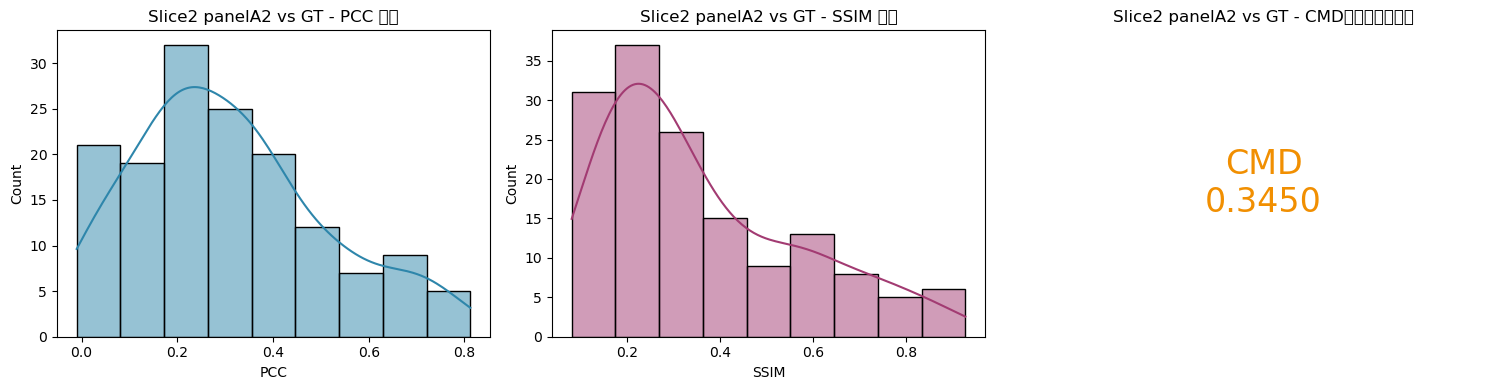

In [10]:
adata2_gt = se.pp.Read_Xenium(file_path2, obs_path2)[adata2.obs_names]
adata2_gt = se.pp.Preprocess_adata(adata2_gt, cell_mRNA_cutoff=0, selected_genes=panelA)

graph = se.pp.Build_graph(adata2_gt.obsm['spatial'], graph_type='knn', weighted='gaussian', apply_normalize='row', return_type='coo')
ssim, ssim_reduce = se.utils.Compute_metrics(adata2_gt.X.copy(), panelA2.copy(), metric='ssim', graph=graph, reduce='mean')
pcc,  pcc_reduce  = se.utils.Compute_metrics(adata2_gt.X.copy(), panelA2.copy(), metric='pcc',                  reduce='mean')
cmd,  cmd_reduce  = se.utils.Compute_metrics(adata2_gt.X.copy(), panelA2.copy(), metric='cmd',                  reduce='mean')
print('Slice2 上预测 Panel A 评估，PCC: ', pcc_reduce, ' SSIM: ', ssim_reduce, ' CMD: ', cmd_reduce)

_ = plot_metric_distribution(pcc, ssim, cmd, var_names=adata2_gt.var_names, title_prefix='Slice2 panelA2 vs GT')

## A.4 空间可视化

把测序区域内的预测和测序区域外的推断拼在同一张图上展示。

### A.4.1 在 Slice 1 上可视化预测的 Panel B（基因 ZEB2）

In [11]:
# 估计测序区域边界，用于把区外细胞过滤出来
outx, outy   = out_spatial1['image_col'].values, out_spatial1['image_row'].values
innerx, innery = adata1.obsm['image_coor'][:, 0], adata1.obsm['image_coor'][:, 1]
boundary_func, y_estimate = se.utils.Estimate_boundary(innerx, innery)
y_boundary   = boundary_func(outx) - 100
selection1   = (outx < innerx.min() + 50) + (outx > innerx.max() - 50) + (outy < innery.min() + 50)
selection2   = (outx > innerx.min()) & (outx < innerx.max()) & (outy > y_boundary)
selection_a  = selection1 + selection2

Estimating y boundary


100%|██████████| 106/106 [00:00<00:00, 4654.43it/s]


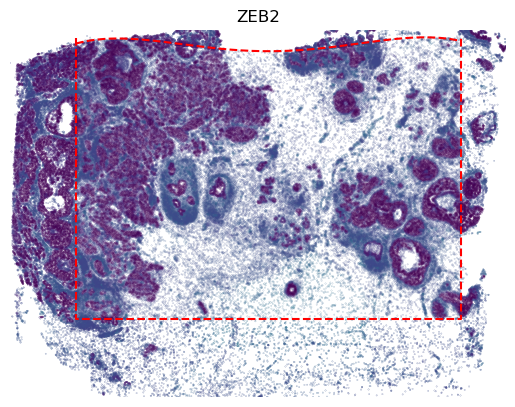

In [12]:
gene_name = 'ZEB2'
gene_idx  = np.where(adata2.var_names == gene_name)[0]
vmin, vmax = adata2[:, gene_name].X.min(), adata2[:, gene_name].X.max()

value = panelB1[:, gene_idx]
x, y  = adata1.obsm['image_coor'][:, 0], adata1.obsm['image_coor'][:, 1]
plt.scatter(x, y, c=value, vmin=0, vmax=vmax, s=0.01)

value = panelB1_out[:, gene_idx]
x, y  = out_spatial1['image_col'], out_spatial1['image_row']
plt.scatter(x[selection_a], y[selection_a], c=value[selection_a], vmin=0, vmax=vmax, s=0.02)

plt.plot(np.arange(innerx.min(), innerx.max()), boundary_func(np.arange(innerx.min(), innerx.max())), color='red', linestyle='--')
plt.plot([innerx.min(), innerx.min(), innerx.max(), innerx.max()], [innery.max(), innery.min(), innery.min(), innery.max()],
         color='red', linestyle='--')

plt.title(gene_name)
plt.xlim((x.min(), x.max())); plt.ylim((y.min(), y.max()))
plt.axis('off'); ax = plt.gca(); ax.set_aspect(1)
plt.show()

### A.4.2 在 Slice 2 上可视化预测的 Panel A（基因 EPCAM）

In [13]:
col_min, col_max = adata2.obsm['image_coor'][:, 1].min(), adata2.obsm['image_coor'][:, 1].max()
row_min, row_max = adata2.obsm['image_coor'][:, 0].min(), adata2.obsm['image_coor'][:, 0].max()
selection_b = (out_spatial2['image_row'] > row_min) & (out_spatial2['image_row'] < row_max) & \
              (out_spatial2['image_col'] > col_min) & (out_spatial2['image_col'] < col_max)

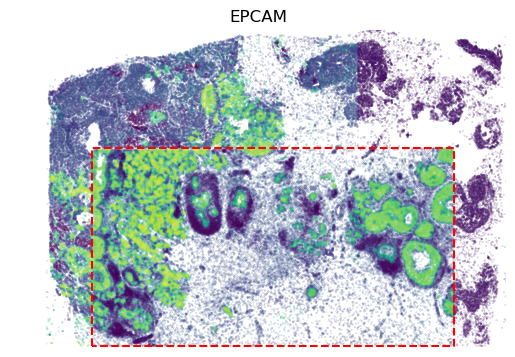

In [14]:
gene_name = 'EPCAM'
gene_idx  = np.where(adata1.var_names == gene_name)[0]

value = panelA2[:, gene_idx]
vmax  = value.max()
x, y  = adata2.obsm['image_coor'][:, 0], adata2.obsm['image_coor'][:, 1]
plt.scatter(x, y, c=value, vmax=vmax, s=0.01)

x = [row_min, row_min, row_max, row_max, row_min]
y = [col_min, col_max, col_max, col_min, col_min]
plt.plot(x, y, color='red', linestyle='--')

value = panelA2_out[:, gene_idx]
x, y  = out_spatial2['image_col'], out_spatial2['image_row']
plt.scatter(y[~selection_b], x[~selection_b], c=value[~selection_b], s=0.01, vmin=0)

plt.title(gene_name)
plt.ylim((0, x.max())); plt.xlim((0, y.max()))
plt.axis('off'); ax = plt.gca(); ax.set_aspect(1)
plt.show()

---
# Part B：跨组学对角整合（Tutorial 4，转录组 ↔ 蛋白组）

Slice 1 仅有蛋白组（`cell_protein_matrix.h5ad`），Slice 2 仅有转录组。SpatialEx+ 让两个切片均可拥有蛋白组 + 转录组的多组学表达。

## B.1 Slice 1：读入 Rep1 蛋白组并预处理

In [15]:
# 缓存路径
file_path1_p = data_root + sample_name1 + '/cell_protein_matrix.h5ad'
cache_b1 = data_root + sample_name1 + '/adata_protein_uni_res64.h5ad'

if os.path.exists(cache_b1):
    print(f'[Part B - Rep1 蛋白] 直接读取缓存: {cache_b1}')
    adata1 = sc.read_h5ad(cache_b1)
else:
    print('[Part B - Rep1 蛋白] 首次运行，开始预处理 + UNI 编码...')
    adata1 = sc.read_h5ad(file_path1_p)
    adata1.var_names = adata1.var_names.astype(str)
    adata1.obs_names = adata1.obs_names.astype(str)
    obs = pd.read_csv(obs_path1, index_col=0)
    obs.index = obs.index.astype(str)
    adata1 = adata1[obs.index]
    adata1.obs = obs
    adata1.obsm['spatial'] = adata1.obs[['x_centroid', 'y_centroid']].values
    adata1.var_names_make_unique()
    sc.pp.scale(adata1)

    img, scale = se.pp.Read_HE_image(img_path1)
    trans_mtx  = pd.read_csv(transform_mtx_path1, header=None).values
    adata1     = se.pp.Register_physical_to_pixel(adata1, trans_mtx, scale)
    he_patches, adata1 = se.pp.Tiling_HE_patches(resolution, adata1, img)
    adata1 = se.pp.Extract_HE_patches_representaion(
        he_patches, store_key='he', adata=adata1, image_encoder='uni', device=device
    )
    adata1.write_h5ad(cache_b1)
    print(f'[Part B - Rep1 蛋白] 缓存已保存: {cache_b1}')

print(f'adata1(蛋白): {adata1.shape}, he={adata1.obsm["he"].shape}')

[Part B - Rep1 蛋白] 直接读取缓存: /data1/linxin/1/SpatialEx/data/raw_data/HBC/Human_Breast_Cancer_Rep1/adata_protein_uni_res64.h5ad
adata1(蛋白): (167780, 2), he=(167780, 1024)


## B.2 Slice 2：读入 Rep2 转录组并预处理

In [16]:
file_path2          = data_root + sample_name2 + '/cell_feature_matrix.h5'
obs_path2           = data_root + sample_name2 + '/cells.csv'
img_path2           = data_root + sample_name2 + '/Xenium_FFPE_Human_Breast_Cancer_Rep2_he_image.ome.tif'
transform_mtx_path2 = data_root + sample_name2 + '/Xenium_FFPE_Human_Breast_Cancer_Rep2_he_imagealignment.csv'

# 缓存路径：完整转录组的 UNI 编码（与 run_SpatialEx.ipynb 中的 Rep2 缓存等价，可共用）
cache_b2 = data_root + sample_name2 + '/adata_preprocessed_uni_res64.h5ad'

if os.path.exists(cache_b2):
    print(f'[Part B - Rep2 转录组] 直接读取缓存: {cache_b2}')
    adata2 = sc.read_h5ad(cache_b2)
else:
    print('[Part B - Rep2 转录组] 首次运行，开始预处理 + UNI 编码...')
    adata2 = se.pp.Read_Xenium(file_path2, obs_path2)
    adata2 = se.pp.Preprocess_adata(adata2)

    img, scale     = se.pp.Read_HE_image(img_path2)
    transform_mtx  = pd.read_csv(transform_mtx_path2, header=None).values
    adata2         = se.pp.Register_physical_to_pixel(adata2, transform_mtx, scale=scale)
    he_patches, adata2 = se.pp.Tiling_HE_patches(resolution, adata2, img)
    adata2 = se.pp.Extract_HE_patches_representaion(
        he_patches, store_key='he', adata=adata2, image_encoder='uni', device=device
    )
    adata2.write_h5ad(cache_b2)
    print(f'[Part B - Rep2 转录组] 缓存已保存: {cache_b2}')

print(f'adata2(转录组): {adata2.shape}, he={adata2.obsm["he"].shape}')

[Part B - Rep2 转录组] 直接读取缓存: /data1/linxin/1/SpatialEx/data/raw_data/HBC/Human_Breast_Cancer_Rep2/adata_preprocessed_uni_res64.h5ad
adata2(转录组): (111555, 313), he=(111555, 1024)


## B.3 训练 SpatialEx+（蛋白 ↔ 转录组）并互相补全

In [17]:
graph1 = se.pp.Build_hypergraph_spatial_and_HE(adata1, num_neighbors, graph_kind='spatial', return_type='crs')
graph2 = se.pp.Build_hypergraph_spatial_and_HE(adata2, num_neighbors, graph_kind='spatial', return_type='crs')

# Slice1（蛋白） + Slice2（转录组）的对角整合训练
# platform='Visium' 让训练走全量单细胞分辨率 MSE，不依赖 spot 聚合矩阵（agg_mtx）
# 若安装的是仓库最新版可改为 use_agg=False；旧版无此参数时用 platform='Visium' 等价
spatialexp = se.SpatialExP(adata1, adata2, graph1, graph2, device=device, epochs=epochs, platform='Visium')
spatialexp.train()

# Slice1 本身有蛋白（Panel A）：直接预测可拿到自己的 Panel B（转录组）
# Slice2 本身有转录组（Panel B）：间接映射可拿到 Panel A（蛋白组）
panelB1 = spatialexp.inference_direct  (adata1.obsm['he'], graph1, panel='panelB')
panelA2 = spatialexp.inference_indirect(adata2.obsm['he'], graph2, panel='panelA')

167780  cells are included in its nearest spot!
111555  cells are included in its nearest spot!


=================================== Start training =========================================


100%|██████████| 500/500 [02:54<00:00,  2.86it/s]


In [18]:
# 测序区域之外的 H&E + 坐标，重新构图后做扩展推断（使用未过滤的全量坐标）
out_spatial1 = pd.read_csv(data_root + sample_name1 + '/HBRC_Rep1_cell_coor.csv', index_col=0)
out_spatial2 = pd.read_csv(data_root + sample_name2 + '/HBRC_Rep2_cell_coor.csv', index_col=0)
out_he1      = np.load(data_root + sample_name1 + '/HBRC_Rep1_Out_uni.npy')
out_he2      = np.load(data_root + sample_name2 + '/HBRC_Rep2_Out_uni.npy')

graph1_out = se.pp.Build_hypergraph(out_spatial1.values, num_neighbors=num_neighbors, normalize=True)
graph2_out = se.pp.Build_hypergraph(out_spatial2.values, num_neighbors=num_neighbors, normalize=True)

panelA1_out = spatialexp.inference_indirect(out_he1, graph1_out, panel='panelA')
panelA2_out = spatialexp.inference_indirect(out_he2, graph2_out, panel='panelA')
panelB1_out = spatialexp.inference_direct  (out_he1, graph1_out, panel='panelB')
panelB2_out = spatialexp.inference_direct  (out_he2, graph2_out, panel='panelB')

## B.4 定量评估 + 指标可视化

在 Slice 1 上评估预测得到的转录组（基因级 PCC / SSIM / CMD）。

x shape is  167780
cell number is less than 200000
Slice 1 基因级评估（蛋白→转录组），PCC:  0.23643313  SSIM:  0.39144792338369677  CMD:  0.250538146445636


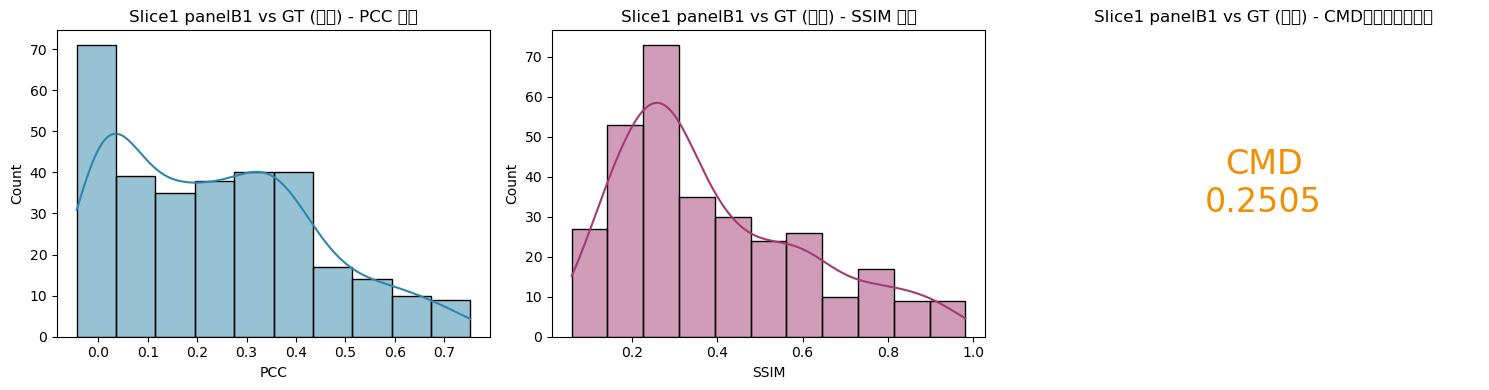

In [19]:
# Slice 1 转录组真值
file_path1_gt = data_root + sample_name1 + '/cell_feature_matrix.h5'
obs_path1_gt  = data_root + sample_name1 + '/cells.csv'
adata1_gt     = se.pp.Read_Xenium(file_path1_gt, obs_path1_gt)[adata1.obs_names]
adata1_gt     = se.pp.Preprocess_adata(adata1_gt, cell_mRNA_cutoff=0)

graph = se.pp.Build_graph(adata1_gt.obsm['spatial'], graph_type='knn', weighted='gaussian', apply_normalize='row', return_type='coo')
pcc,  pcc_reduce  = se.utils.Compute_metrics(adata1_gt.X.copy(), panelB1.copy(), metric='pcc')
ssim, ssim_reduce = se.utils.Compute_metrics(adata1_gt.X.copy(), panelB1.copy(), metric='ssim', graph=graph)
cmd,  cmd_reduce  = se.utils.Compute_metrics(adata1_gt.X.copy(), panelB1.copy(), metric='cmd')
print('Slice 1 基因级评估（蛋白→转录组），PCC: ', pcc_reduce, ' SSIM: ', ssim_reduce, ' CMD: ', cmd_reduce)

_ = plot_metric_distribution(pcc, ssim, cmd, var_names=adata1_gt.var_names, title_prefix='Slice1 panelB1 vs GT (基因)')

## B.5 空间可视化

### B.5.1 Rep1：可视化蛋白 CD20 与对应基因 MS4A1

In [20]:
outx, outy     = out_spatial1['image_col'].values, out_spatial1['image_row'].values
innerx, innery = adata1.obsm['image_coor'][:, 0], adata1.obsm['image_coor'][:, 1]
boundary_func, y_estimate = se.utils.Estimate_boundary(innerx, innery)
y_boundary   = boundary_func(outx) - 100
selection1   = (outx < innerx.min() + 50) + (outx > innerx.max() - 50) + (outy < innery.min() + 50)
selection2   = (outx > innerx.min()) & (outx < innerx.max()) & (outy > y_boundary)
selection_b1 = selection1 + selection2

Estimating y boundary


100%|██████████| 106/106 [00:00<00:00, 4696.12it/s]


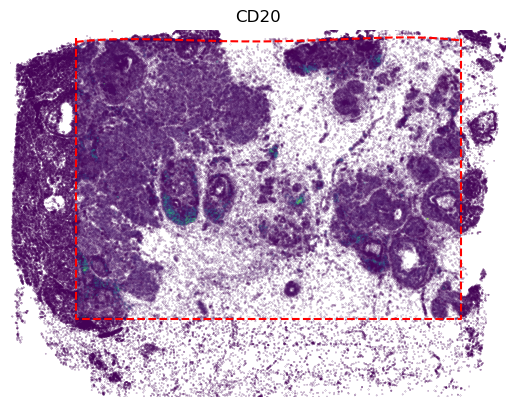

In [21]:
# 蛋白 CD20：Slice1 区内是真值，区外是 SpatialEx+ 推断
protein_name = 'CD20'
protein_idx  = np.where(adata1.var_names == protein_name)[0]
vmin, vmax   = adata1[:, protein_name].X.min(), adata1[:, protein_name].X.max()

value = adata1[:, protein_name].X
x, y  = adata1.obsm['image_coor'][:, 0], adata1.obsm['image_coor'][:, 1]
plt.scatter(x, y, c=value, s=0.01)

value = panelA1_out[:, protein_idx]
x, y  = out_spatial1['image_col'], out_spatial1['image_row']
plt.scatter(x[selection_b1], y[selection_b1], c=value[selection_b1], vmax=vmax, s=0.02)

plt.plot(np.arange(innerx.min(), innerx.max()), boundary_func(np.arange(innerx.min(), innerx.max())), color='red', linestyle='--')
plt.plot([innerx.min(), innerx.min(), innerx.max(), innerx.max()], [innery.max(), innery.min(), innery.min(), innery.max()],
         color='red', linestyle='--')

plt.title(protein_name)
plt.xlim((x.min(), x.max())); plt.ylim((y.min(), y.max()))
plt.axis('off'); ax = plt.gca(); ax.set_aspect(1)
plt.show()

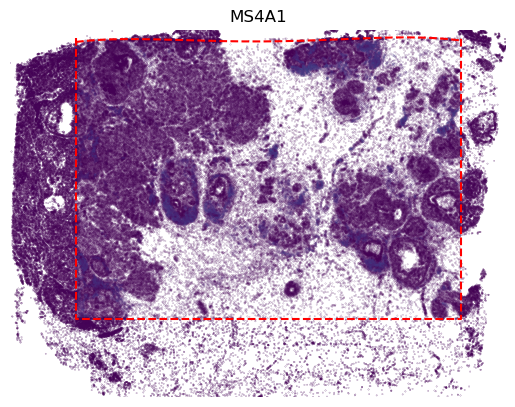

In [22]:
# 基因 MS4A1（编码 CD20 蛋白）：Slice1 区内是 SpatialEx+ 直接推断，区外是扩展推断
gene_name = 'MS4A1'
gene_idx  = np.where(adata2.var_names == gene_name)[0]
vmin, vmax = adata2[:, gene_name].X.min(), adata2[:, gene_name].X.max()

value = panelB1[:, gene_idx]
x, y  = adata1.obsm['image_coor'][:, 0], adata1.obsm['image_coor'][:, 1]
plt.scatter(x, y, c=value, vmin=0, vmax=vmax, s=0.01)

value = panelB1_out[:, gene_idx]
x, y  = out_spatial1['image_col'], out_spatial1['image_row']
plt.scatter(x[selection_b1], y[selection_b1], c=value[selection_b1], vmin=0, vmax=vmax, s=0.02)

plt.plot(np.arange(innerx.min(), innerx.max()), boundary_func(np.arange(innerx.min(), innerx.max())), color='red', linestyle='--')
plt.plot([innerx.min(), innerx.min(), innerx.max(), innerx.max()], [innery.max(), innery.min(), innery.min(), innery.max()],
         color='red', linestyle='--')

plt.title(gene_name)
plt.xlim((x.min(), x.max())); plt.ylim((y.min(), y.max()))
plt.axis('off'); ax = plt.gca(); ax.set_aspect(1)
plt.show()

### B.5.2 Rep2：可视化预测蛋白 CD20 与原生基因 MS4A1

In [23]:
col_min, col_max = adata2.obsm['image_coor'][:, 1].min(), adata2.obsm['image_coor'][:, 1].max()
row_min, row_max = adata2.obsm['image_coor'][:, 0].min(), adata2.obsm['image_coor'][:, 0].max()
selection_b2 = (out_spatial2['image_row'] > row_min) & (out_spatial2['image_row'] < row_max) & \
               (out_spatial2['image_col'] > col_min) & (out_spatial2['image_col'] < col_max)

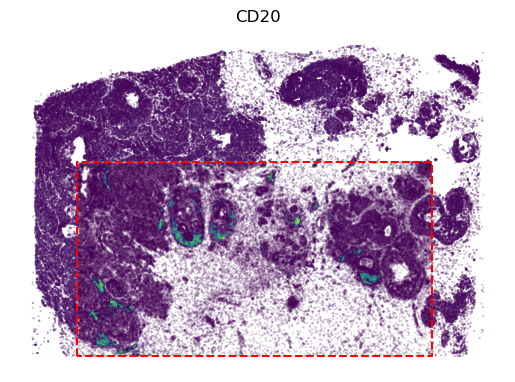

In [24]:
# Slice2 上预测的蛋白 CD20
protein_name = 'CD20'
gene_idx     = np.where(adata1.var_names == protein_name)[0]
vmin, vmax   = adata1[:, protein_name].X.min(), adata1[:, protein_name].X.max()

value = panelA2[:, gene_idx]
vmax  = value.max()
x, y  = adata2.obsm['image_coor'][:, 0], adata2.obsm['image_coor'][:, 1]
plt.scatter(x, y, c=value, vmin=vmin + 1, vmax=vmax, s=0.01)

value = panelA2_out[:, gene_idx]
x, y  = out_spatial2['image_col'], out_spatial2['image_row']
plt.scatter(y[~selection_b2], x[~selection_b2], c=value[~selection_b2], vmax=vmax, s=0.02)

x = [row_min, row_min, row_max, row_max, row_min]
y = [col_min, col_max, col_max, col_min, col_min]
plt.plot(x, y, color='red', linestyle='--')

plt.title(protein_name)
plt.axis('off'); ax = plt.gca(); ax.set_aspect(1)
plt.show()

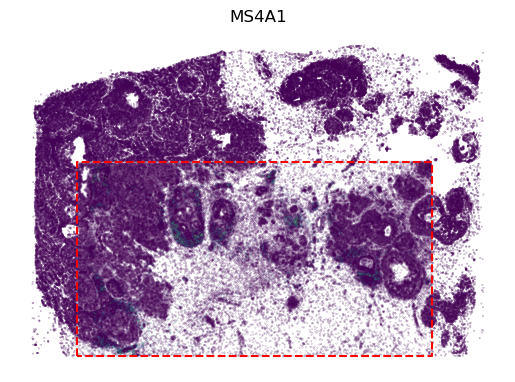

In [25]:
# Slice2 原生 MS4A1 与区外推断
gene_name = 'MS4A1'
gene_idx  = np.where(adata2.var_names == gene_name)[0]

value = adata2[:, gene_name].X
vmax  = value.max()
x, y  = adata2.obsm['image_coor'][:, 0], adata2.obsm['image_coor'][:, 1]
plt.scatter(x, y, c=value, vmin=0, s=0.01)

value = panelB2_out[:, gene_idx]
x, y  = out_spatial2['image_col'], out_spatial2['image_row']
plt.scatter(y[~selection_b2], x[~selection_b2], c=value[~selection_b2], vmin=0, vmax=vmax, s=0.02)

x = [row_min, row_min, row_max, row_max, row_min]
y = [col_min, col_max, col_max, col_min, col_min]
plt.plot(x, y, color='red', linestyle='--')

plt.title(gene_name)
plt.axis('off'); ax = plt.gca(); ax.set_aspect(1)
plt.show()